In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, f1_score)
from collections import Counter
import joblib, warnings, random
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cuda


In [15]:
df = pd.read_csv('../Dataset/processed/final_dataset_preprocessed_v2.csv')

FEATURE_COLS = [c for c in df.columns if c != 'target']
TARGET_COL   = 'target'

X_raw = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

# Log-compress wide-range columns
for col in ['water_stress', 'combined_stress', 'temp_humidity_index']:
    idx = FEATURE_COLS.index(col)
    X_raw[:, idx] = np.log1p(X_raw[:, idx])

print(f"X shape : {X_raw.shape}")
print(f"y dist  : {Counter(y_raw.astype(int))}")

X shape : (9129, 40)
y dist  : Counter({np.int64(1): 5350, np.int64(0): 3779})


In [16]:
def block_split(X, y, train_frac=0.70, val_frac=0.15, block_size=30, seed=42):
    n_blocks = len(X) // block_size
    idx      = np.arange(n_blocks)
    rng      = np.random.default_rng(seed)
    rng.shuffle(idx)

    n_tr  = int(n_blocks * train_frac)
    n_val = int(n_blocks * val_frac)

    def collect(block_ids):
        rows = []
        for b in sorted(block_ids):
            rows.extend(range(b * block_size,
                              min((b + 1) * block_size, len(X))))
        return np.array(rows)

    tr  = collect(idx[:n_tr])
    val = collect(idx[n_tr:n_tr + n_val])
    te  = collect(idx[n_tr + n_val:])
    return X[tr], y[tr], X[val], y[val], X[te], y[te]


X_train, y_train, X_val, y_val, X_test, y_test = block_split(X_raw, y_raw)

for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    c = Counter(yy.astype(int))
    print(f"{name:6s}: 0={c[0]:4d} ({c[0]/len(yy):.1%})  "
          f"1={c[1]:4d} ({c[1]/len(yy):.1%})  n={len(yy)}")

Train : 0=2525 (39.7%)  1=3835 (60.3%)  n=6360
Val   : 0= 574 (42.5%)  1= 776 (57.5%)  n=1350
Test  : 0= 680 (48.2%)  1= 730 (51.8%)  n=1410


In [17]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, 'scaler_v3.pkl')
print("Scaler saved.")

Scaler saved.


In [18]:
# UPGRADE 1: instead of predicting only t+1,
# each sample carries three labels: t+1, t+3, t+7
# The window still looks back TIME_STEPS days.

HORIZONS   = [1, 3, 7]   # days ahead to predict
TIME_STEPS = 7            # look-back window

def make_multihorizon_sequences(X, y, time_steps, horizons):
    """
    Returns:
        Xs : (n, time_steps, features)
        ys : (n, len(horizons))   — one binary label per horizon
    """
    max_h = max(horizons)
    Xs, ys = [], []
    for i in range(len(X) - time_steps - max_h):
        Xs.append(X[i : i + time_steps])
        ys.append([y[i + time_steps + h - 1] for h in horizons])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32))


X_tr_seq, y_tr_seq = make_multihorizon_sequences(X_train_sc, y_train, TIME_STEPS, HORIZONS)
X_va_seq, y_va_seq = make_multihorizon_sequences(X_val_sc,   y_val,   TIME_STEPS, HORIZONS)
X_te_seq, y_te_seq = make_multihorizon_sequences(X_test_sc,  y_test,  TIME_STEPS, HORIZONS)

print(f"X_train : {X_tr_seq.shape}")
print(f"y_train : {y_tr_seq.shape}  ← [samples, 3 horizons]")
print(f"\nHorizon label balance (train):")
for i, h in enumerate(HORIZONS):
    c = Counter(y_tr_seq[:, i].astype(int))
    print(f"  t+{h:1d}: 0={c[0]:4d} ({c[0]/len(y_tr_seq):.1%})  "
          f"1={c[1]:4d} ({c[1]/len(y_tr_seq):.1%})")

X_train : (6346, 7, 40)
y_train : (6346, 3)  ← [samples, 3 horizons]

Horizon label balance (train):
  t+1: 0=2518 (39.7%)  1=3828 (60.3%)
  t+3: 0=2516 (39.6%)  1=3830 (60.4%)
  t+7: 0=2512 (39.6%)  1=3834 (60.4%)


SMOTE per horizon 

In [19]:
from imblearn.over_sampling import SMOTE

n_seq, ts, n_feat = X_tr_seq.shape
X_flat = X_tr_seq.reshape(n_seq, ts * n_feat)

# Resample using t+1 label as the reference (most immediate signal)
smote        = SMOTE(random_state=SEED)
X_res, y_ref = smote.fit_resample(X_flat, y_tr_seq[:, 0].astype(int))

# For the synthetic rows, propagate all horizon labels using nearest-neighbour index
# imblearn tracks which original samples the synthetics are derived from
# Simpler robust approach: resample full y_tr_seq with same index
from imblearn.over_sampling import SMOTE as _SMOTE

class MultiLabelSMOTE:
    """Apply SMOTE using one reference column; replicate resampling across all label cols."""
    def fit_resample(self, X, Y, ref_col=0):
        sm = _SMOTE(random_state=SEED)
        X_res, y_ref_res = sm.fit_resample(X, Y[:, ref_col].astype(int))
        n_orig  = len(X)
        n_synth = len(X_res) - n_orig
        # For synthetic rows: sample horizon labels from existing class-1 rows
        class1_idx   = np.where(Y[:, ref_col] == 1)[0]
        synth_labels = Y[np.random.choice(class1_idx, n_synth, replace=True)]
        Y_res = np.vstack([Y, synth_labels])
        return X_res, Y_res

mls          = MultiLabelSMOTE()
X_res, Y_res = mls.fit_resample(X_flat, y_tr_seq)

X_tr_bal = X_res.reshape(-1, ts, n_feat).astype(np.float32)
y_tr_bal = Y_res.astype(np.float32)

print(f"Before SMOTE : {X_tr_seq.shape}")
print(f"After  SMOTE : {X_tr_bal.shape}")
for i, h in enumerate(HORIZONS):
    c = Counter(y_tr_bal[:, i].astype(int))
    print(f"  t+{h}: 0={c[0]} ({c[0]/len(y_tr_bal):.1%})  1={c[1]} ({c[1]/len(y_tr_bal):.1%})")

Before SMOTE : (6346, 7, 40)
After  SMOTE : (7656, 7, 40)
  t+1: 0=2518 (32.9%)  1=5138 (67.1%)
  t+3: 0=2567 (33.5%)  1=5089 (66.5%)
  t+7: 0=2577 (33.7%)  1=5079 (66.3%)


In [20]:
class FarmDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]

BATCH_SIZE   = 64
train_loader = DataLoader(FarmDataset(X_tr_bal, y_tr_bal),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FarmDataset(X_va_seq, y_va_seq),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(FarmDataset(X_te_seq, y_te_seq),
                          batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Batch X : {xb.shape}   y : {yb.shape}")

Batch X : torch.Size([64, 7, 40])   y : torch.Size([64, 3])


In [21]:
class TemporalAttention(nn.Module):
    """
    Learns a scalar weight for each timestep.
    attn_weights = softmax(W * tanh(hidden_states))
    context      = weighted sum of hidden states
    Returns context vector + weights (weights used for explainability).
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.W = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden_states):
        # hidden_states : (batch, time_steps, hidden_size)
        scores  = self.W(torch.tanh(hidden_states))     # (batch, time_steps, 1)
        weights = torch.softmax(scores, dim=1)           # (batch, time_steps, 1)
        context = (weights * hidden_states).sum(dim=1)   # (batch, hidden_size)
        return context, weights.squeeze(-1)              # weights: (batch, time_steps)


class FarmLSTM_v3(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, n_horizons=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attention = TemporalAttention(hidden_size)

        self.shared_head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
        )
        # Separate output head per horizon — each horizon is a different task
        self.horizon_heads = nn.ModuleList([
            nn.Sequential(nn.Dropout(dropout / 2), nn.Linear(64, 1))
            for _ in range(n_horizons)
        ])

    def forward(self, x):
        hidden_states, _   = self.lstm(x)             # (B, T, H)
        context, attn_w    = self.attention(hidden_states)
        shared             = self.shared_head(context) # (B, 64)
        logits             = torch.cat(
            [head(shared) for head in self.horizon_heads], dim=1
        )                                              # (B, n_horizons)
        return logits, attn_w


INPUT_SIZE = X_tr_bal.shape[2]   # 29
N_HORIZONS = len(HORIZONS)       # 3

model = FarmLSTM_v3(input_size=INPUT_SIZE, hidden_size=128,
                    num_layers=2, dropout=0.3,
                    n_horizons=N_HORIZONS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

FarmLSTM_v3(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attention): TemporalAttention(
    (W): Linear(in_features=128, out_features=1, bias=False)
  )
  (shared_head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (horizon_heads): ModuleList(
    (0-2): 3 x Sequential(
      (0): Dropout(p=0.15, inplace=False)
      (1): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

Trainable parameters: 227,971


Multi task loss

In [22]:
# One BCE loss per horizon, averaged
# Could weight them (near-term > far-term) but equal works well as baseline

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

def multitask_loss(logits, targets, criterion):
    """Average BCE loss across all horizon heads."""
    losses = [criterion(logits[:, i], targets[:, i])
              for i in range(logits.shape[1])]
    return torch.stack(losses).mean(), losses

In [23]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits, _  = model(xb)
        loss, _    = multitask_loss(logits, yb, criterion)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
        total      += len(xb)
    return total_loss / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total = 0, 0
    all_probs  = [[] for _ in HORIZONS]
    all_labels = [[] for _ in HORIZONS]
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb   = xb.to(DEVICE), yb.to(DEVICE)
            logits, _ = model(xb)
            loss, _   = multitask_loss(logits, yb, criterion)
            total_loss += loss.item() * len(xb)
            total      += len(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            for i in range(len(HORIZONS)):
                all_probs[i].extend(probs[:, i])
                all_labels[i].extend(yb[:, i].cpu().numpy())

    aucs = [roc_auc_score(all_labels[i], all_probs[i]) for i in range(len(HORIZONS))]
    return total_loss / total, aucs, all_probs, all_labels


EPOCHS        = 50
best_val_loss = float('inf')
history       = {'train_loss': [], 'val_loss': [], 'val_aucs': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss                          = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_aucs, _, _         = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_v3.pt')
        tag = '  ← saved'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        auc_str = '  '.join([f't+{h}={a:.3f}' for h, a in zip(HORIZONS, val_aucs)])
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"tr={tr_loss:.4f}  val={val_loss:.4f} | {auc_str}{tag}")

Epoch   1/50 | tr=0.4467  val=0.3882 | t+1=0.971  t+3=0.957  t+7=0.932  ← saved
Epoch   5/50 | tr=0.3736  val=0.3555 | t+1=0.967  t+3=0.961  t+7=0.936
Epoch  10/50 | tr=0.3646  val=0.3556 | t+1=0.976  t+3=0.965  t+7=0.940
Epoch  15/50 | tr=0.3549  val=0.3740 | t+1=0.968  t+3=0.953  t+7=0.926
Epoch  20/50 | tr=0.3443  val=0.3770 | t+1=0.965  t+3=0.950  t+7=0.925
Epoch  25/50 | tr=0.3317  val=0.3712 | t+1=0.965  t+3=0.952  t+7=0.926
Epoch  30/50 | tr=0.3268  val=0.3961 | t+1=0.962  t+3=0.949  t+7=0.919
Epoch  35/50 | tr=0.3209  val=0.3862 | t+1=0.964  t+3=0.951  t+7=0.920
Epoch  40/50 | tr=0.3197  val=0.3940 | t+1=0.963  t+3=0.950  t+7=0.918
Epoch  45/50 | tr=0.3147  val=0.3983 | t+1=0.962  t+3=0.949  t+7=0.916
Epoch  50/50 | tr=0.3160  val=0.3984 | t+1=0.962  t+3=0.949  t+7=0.916


In [24]:
model.load_state_dict(torch.load('best_model_v3.pt', map_location=DEVICE))
_, _, te_probs, te_labels = eval_epoch(model, test_loader, criterion)

print("=" * 56)
print("  TEST RESULTS — PER HORIZON")
print("=" * 56)
for i, h in enumerate(HORIZONS):
    probs  = np.array(te_probs[i])
    labels = np.array(te_labels[i]).astype(int)
    preds  = (probs >= 0.5).astype(int)
    auc    = roc_auc_score(labels, probs)
    print(f"\n── Horizon t+{h} ──")
    print(classification_report(labels, preds,
                                target_names=['Not stressed', 'Stressed']))
    print(f"  ROC-AUC : {auc:.4f}")

  TEST RESULTS — PER HORIZON

── Horizon t+1 ──
              precision    recall  f1-score   support

Not stressed       0.94      0.87      0.90       673
    Stressed       0.88      0.94      0.91       723

    accuracy                           0.91      1396
   macro avg       0.91      0.91      0.91      1396
weighted avg       0.91      0.91      0.91      1396

  ROC-AUC : 0.9617

── Horizon t+3 ──
              precision    recall  f1-score   support

Not stressed       0.91      0.84      0.87       671
    Stressed       0.86      0.92      0.89       725

    accuracy                           0.88      1396
   macro avg       0.88      0.88      0.88      1396
weighted avg       0.88      0.88      0.88      1396

  ROC-AUC : 0.9407

── Horizon t+7 ──
              precision    recall  f1-score   support

Not stressed       0.87      0.80      0.83       667
    Stressed       0.83      0.89      0.86       729

    accuracy                           0.84      1396
   m

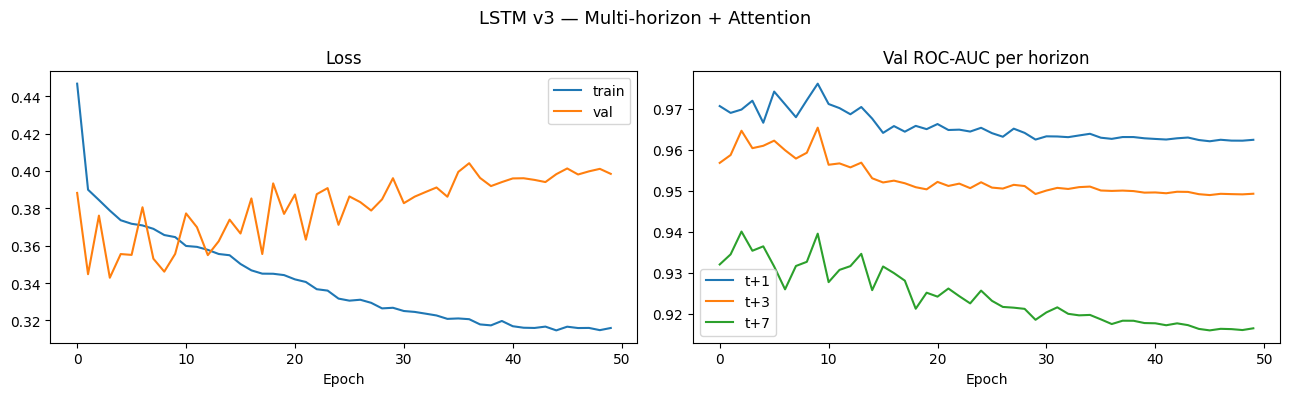

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

aucs_arr = np.array(history['val_aucs'])   # (epochs, 3)
for i, h in enumerate(HORIZONS):
    axes[1].plot(aucs_arr[:, i], label=f't+{h}')
axes[1].set_title('Val ROC-AUC per horizon')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('LSTM v3 — Multi-horizon + Attention', fontsize=13)
plt.tight_layout(); plt.show()

Mean attention weight per timestep (higher = model focuses here more):
  t-6  (Mon)  0.1025  ████████████████████
  t-5  (Tue)  0.1155  ███████████████████████
  t-4  (Wed)  0.1282  █████████████████████████
  t-3  (Thu)  0.1407  ████████████████████████████
  t-2  (Fri)  0.1545  ██████████████████████████████
  t-1  (Sat)  0.1705  ██████████████████████████████████
  t-0  (Sun)  0.1881  █████████████████████████████████████


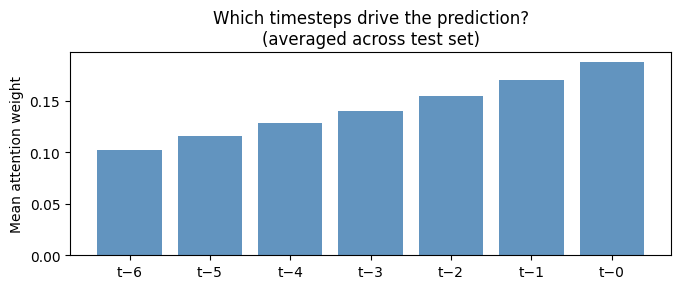

In [26]:
# Pull attention weights for the entire test set
model.eval()
all_attn = []

with torch.no_grad():
    for xb, _ in test_loader:
        _, attn_w = model(xb.to(DEVICE))
        all_attn.append(attn_w.cpu().numpy())

all_attn = np.concatenate(all_attn, axis=0)   # (n_test, time_steps)
mean_attn = all_attn.mean(axis=0)             # average weight per timestep

print("Mean attention weight per timestep (higher = model focuses here more):")
for t, w in enumerate(mean_attn):
    bar = '█' * int(w * 200)
    print(f"  t-{TIME_STEPS - t - 1:1d}  ({['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][t % 7]})  "
          f"{w:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(TIME_STEPS), mean_attn, color='steelblue', alpha=0.85)
ax.set_xticks(range(TIME_STEPS))
ax.set_xticklabels([f't−{TIME_STEPS - i - 1}' for i in range(TIME_STEPS)])
ax.set_ylabel('Mean attention weight')
ax.set_title('Which timesteps drive the prediction?\n(averaged across test set)')
plt.tight_layout(); plt.show()

In [29]:
import shap
print("SHAP version:", shap.__version__)

model.eval()

# ── Step 1: build a pure numpy callable — avoids all tensor/version issues ──
def model_predict_numpy(x_flat_np):
    """
    Takes numpy array (n, TIME_STEPS * INPUT_SIZE)
    Returns numpy array (n,) — t+1 stress probability
    """
    with torch.no_grad():
        t = torch.tensor(x_flat_np, dtype=torch.float32).to(DEVICE)
        x3d       = t.reshape(-1, TIME_STEPS, INPUT_SIZE)
        logits, _ = model(x3d)
        probs     = torch.sigmoid(logits[:, 0])   # t+1 horizon
    return probs.cpu().numpy()                    # always numpy, never tensor

# ── Step 2: background + test samples as plain numpy ──────────────────────
bg_idx  = np.random.choice(len(X_tr_bal), 100, replace=False)
bg_flat = X_tr_bal[bg_idx].reshape(100, TIME_STEPS * INPUT_SIZE)  # numpy

te_idx  = np.random.choice(len(X_te_seq), 50, replace=False)
te_flat = X_te_seq[te_idx].reshape(50, TIME_STEPS * INPUT_SIZE)   # numpy

# Verify callable works before passing to SHAP
test_out = model_predict_numpy(bg_flat[:3])
print(f"Callable test output shape : {test_out.shape}")   # (3,)
print(f"Sample probs               : {test_out}")

# ── Step 3: KernelExplainer — model-agnostic, version-stable ─────────────
# Slower than GradientExplainer but works identically across all shap versions
# Uses bg_flat as the reference distribution (what "no signal" looks like)
explainer = shap.KernelExplainer(model_predict_numpy, bg_flat)

# nsamples=64 is a good balance of speed vs accuracy
# increase to 256 for final results, use 32 for a quick test
shap_values = explainer.shap_values(te_flat, nsamples=64)

# ── Step 4: normalize — KernelExplainer always returns plain numpy ndarray
print(f"\nshap_values type  : {type(shap_values)}")
print(f"shap_values shape : {np.array(shap_values).shape}")

# Handle both possible return shapes
sv = np.array(shap_values)
if sv.ndim == 3:
    sv = sv[0]          # some versions wrap in extra dim → (1, n, feats)
# sv is now (n_samples, TIME_STEPS * INPUT_SIZE)
print(f"sv shape after fix: {sv.shape}")

# ── Step 5: reshape and compute per-feature importance ────────────────────
shap_3d    = sv.reshape(len(te_idx), TIME_STEPS, INPUT_SIZE)  # (50, 7, 29)
shap_feats = np.abs(shap_3d).mean(axis=(0, 1))                # (29,)

print(f"\nshap_3d shape  : {shap_3d.shape}")
print(f"shap_feats shape: {shap_feats.shape}")

print("\nTop 10 most impactful features:")
top_idx = np.argsort(shap_feats)[::-1][:10]
for rank, idx in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {FEATURE_COLS[idx]:35s}  SHAP={shap_feats[idx]:.5f}")

SHAP version: 0.49.1
Callable test output shape : (3,)
Sample probs               : [0.32647714 0.99983156 0.99964416]


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:03<00:00, 16.43it/s]


shap_values type  : <class 'numpy.ndarray'>
shap_values shape : (50, 280)
sv shape after fix: (50, 280)

shap_3d shape  : (50, 7, 40)
shap_feats shape: (40,)

Top 10 most impactful features:
   1. temperature                          SHAP=7930366879648.98438
   2. water_stress                         SHAP=7930366879648.97852
   3. ndvi_health_index                    SHAP=7930366879648.97754
   4. temp_humidity_index                  SHAP=7930366879648.97559
   5. time_index                           SHAP=0.00646
   6. temp_lag2                            SHAP=0.00544
   7. temp_delta                           SHAP=0.00468
   8. fungal_risk                          SHAP=0.00437
   9. humidity_lag1                        SHAP=0.00366
  10. P                                    SHAP=0.00317


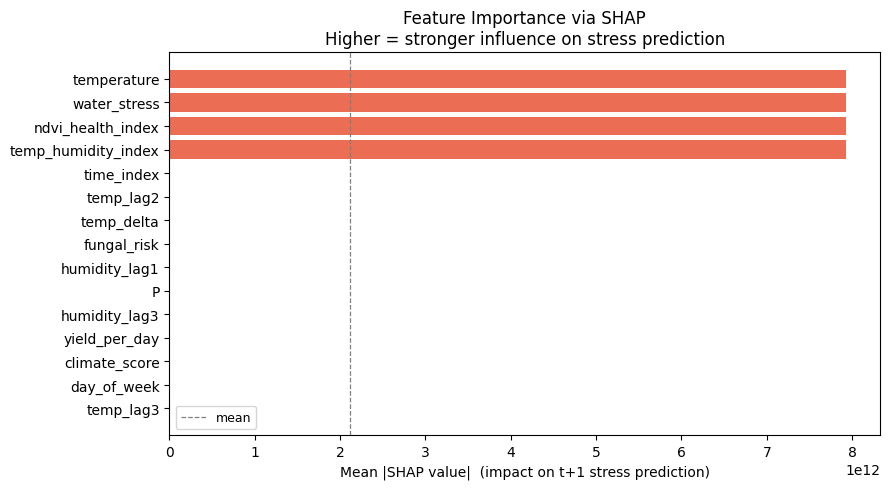

In [30]:
top_n      = 15
top_idx    = np.argsort(shap_feats)[::-1][:top_n]
top_names  = [FEATURE_COLS[i] for i in top_idx]
top_values = shap_feats[top_idx]

fig, ax = plt.subplots(figsize=(9, 5))
colors  = ['#E8593C' if v > top_values.mean() else '#4C9BE8' for v in top_values]
ax.barh(top_names[::-1], top_values[::-1], color=colors[::-1], alpha=0.88)
ax.axvline(top_values.mean(), color='gray', linestyle='--',
           linewidth=0.9, label='mean')
ax.set_xlabel('Mean |SHAP value|  (impact on t+1 stress prediction)')
ax.set_title('Feature Importance via SHAP\nHigher = stronger influence on stress prediction')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

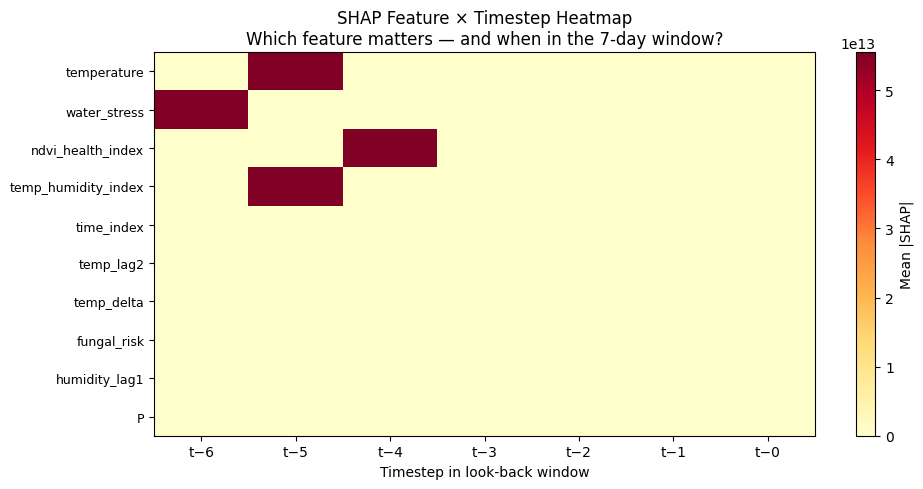

In [31]:
top10_idx   = np.argsort(shap_feats)[::-1][:10]
shap_heat   = np.abs(shap_3d).mean(axis=0)       # (TIME_STEPS, INPUT_SIZE)
shap_heat10 = shap_heat[:, top10_idx].T           # (10, TIME_STEPS)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(shap_heat10, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(10))
ax.set_yticklabels([FEATURE_COLS[i] for i in top10_idx], fontsize=9)
ax.set_xticks(range(TIME_STEPS))
ax.set_xticklabels([f't−{TIME_STEPS - i - 1}' for i in range(TIME_STEPS)])
ax.set_xlabel('Timestep in look-back window')
ax.set_title('SHAP Feature × Timestep Heatmap\nWhich feature matters — and when in the 7-day window?')
plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout()
plt.show()